# Notebook 04 — Contrôleurs de ventilateurs

**Projet :** Juste des Ventilateurs — M2 Data/IA LaPlateforme_  
**Objectif :** Comparer 7 contrôleurs de régulation thermique sur les données collectées depuis jumeaux-chauds.

## Contrôleurs comparés
| # | Contrôleur | Description |
|---|-----------|-------------|
| 0 | `baseline_fixed_1500` | RPM constant 1500 (ralenti) |
| 1 | `baseline_fixed_2500` | RPM constant 2500 (modéré) |
| 2 | `baseline_fixed_4500` | RPM constant 4500 (plein régime) |
| 3 | `baseline_threshold` | Seuils thermiques T_low/T_med/T_high |
| 4 | `baseline_pid` | PID, cible T = 80% × T_shutdown |
| 5 | `supervised` | RandomForest sur action_class oracle |
| 6 | `score_controller` | Score multi-objectif J = α·risk + β·heat + γ·energy + δ·\|ΔRPM\| |

## Métriques
- **mean_rpm** : RPM moyen appliqué (proxy énergie)
- **action_accuracy** : correspondance avec la politique oracle (action_class)
- **rpm_mae** : erreur absolue moyenne vs RPM optimal
- **high_rpm_when_dangerous** : taux de RPM ≥ 3500 quand failure_60s=1
- **nb_shutdowns** : nombre de shutdowns thermiques dans la période de test

In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

# Racine du projet
_root = Path.cwd()
for _candidate in [_root, _root.parent, _root.parent.parent]:
    if (_candidate / 'evaluation').exists() and (_candidate / 'models').exists():
        _root = _candidate
        break
os.chdir(_root)
sys.path.insert(0, str(_root))

RESULTS_FILE = Path('evaluation/results/fan_control_results_failure_60s.json')
LABEL_COL    = 'failure_60s'
RPM_MAX      = 4500

# Palette couleurs par controleur
COLORS = {
    'baseline_fixed_1500': '#95a5a6',
    'baseline_fixed_2500': '#7f8c8d',
    'baseline_fixed_4500': '#2c3e50',
    'baseline_threshold':  '#e74c3c',
    'baseline_pid':        '#f39c12',
    'supervised':          '#2ecc71',
    'score_controller':    '#3498db',
}

print(f'Repertoire de travail : {Path.cwd()}')
print('Imports OK')

Repertoire de travail : C:\AIDEV\LaPlateforme_\juste-des-ventilateurs
Imports OK


## 1. Chargement des résultats

In [2]:
with open(RESULTS_FILE) as f:
    eval_data = json.load(f)

results  = eval_data['results']
df_res   = pd.DataFrame(results).set_index('controller')
names    = [r['controller'] for r in results]
colors   = [COLORS.get(n, '#aaaaaa') for n in names]

print(f"Label : {eval_data['label']}")
print(f"n_train={eval_data['n_train']:,}  n_test={eval_data['n_test']:,}")
print(f"Controleurs : {names}")

Label : failure_60s
n_train=212,864  n_test=45,621
Controleurs : ['baseline_fixed_1500', 'baseline_fixed_2500', 'baseline_fixed_4500', 'baseline_threshold', 'baseline_pid', 'supervised', 'score_controller']


In [3]:
# Tableau récapitulatif
cols_display = ['mean_rpm', 'mean_power_fans_w', 't_mean',
                'nb_shutdowns', 'action_accuracy', 'rpm_mae', 'high_rpm_when_dangerous']
display(df_res[cols_display].style
    .highlight_min(subset=['mean_rpm', 'mean_power_fans_w', 'rpm_mae', 'nb_shutdowns'], color='#c8f7c5')
    .highlight_max(subset=['action_accuracy', 'high_rpm_when_dangerous'], color='#c8f7c5')
    .format({
        'mean_rpm':               '{:.0f}',
        'mean_power_fans_w':      '{:.1f} W',
        't_mean':                 '{:.2f} °C',
        'nb_shutdowns':           '{:.0f}',
        'action_accuracy':        '{:.4f}',
        'rpm_mae':                '{:.1f}',
        'high_rpm_when_dangerous': '{:.3f}',
    })
    .set_caption('Métriques comparatives — contrôleurs de ventilateurs (jeu de test)'))

,mean_rpm,mean_power_fans_w,t_mean,nb_shutdowns,action_accuracy,rpm_mae,high_rpm_when_dangerous
controller,,,,,,,
baseline_fixed_1500,1500,11.1 W,55.32 °C,10,0.3545,1031.0,0.000
baseline_fixed_2500,2500,51.4 W,55.32 °C,10,0.2230,1270.0,0.000
baseline_fixed_4500,4500,300.0 W,55.32 °C,10,0.0955,2764.0,1.000
baseline_threshold,1815,30.3 W,55.32 °C,10,0.4168,715.7,0.105
baseline_pid,1082,26.0 W,55.32 °C,10,0.4598,654.3,0.117
supervised,1736,52.8 W,55.32 °C,10,0.9999,0.1,0.130
score_controller,0,0.0 W,55.32 °C,10,0.2650,1736.0,0.000


## 2. Comparaison des métriques clés

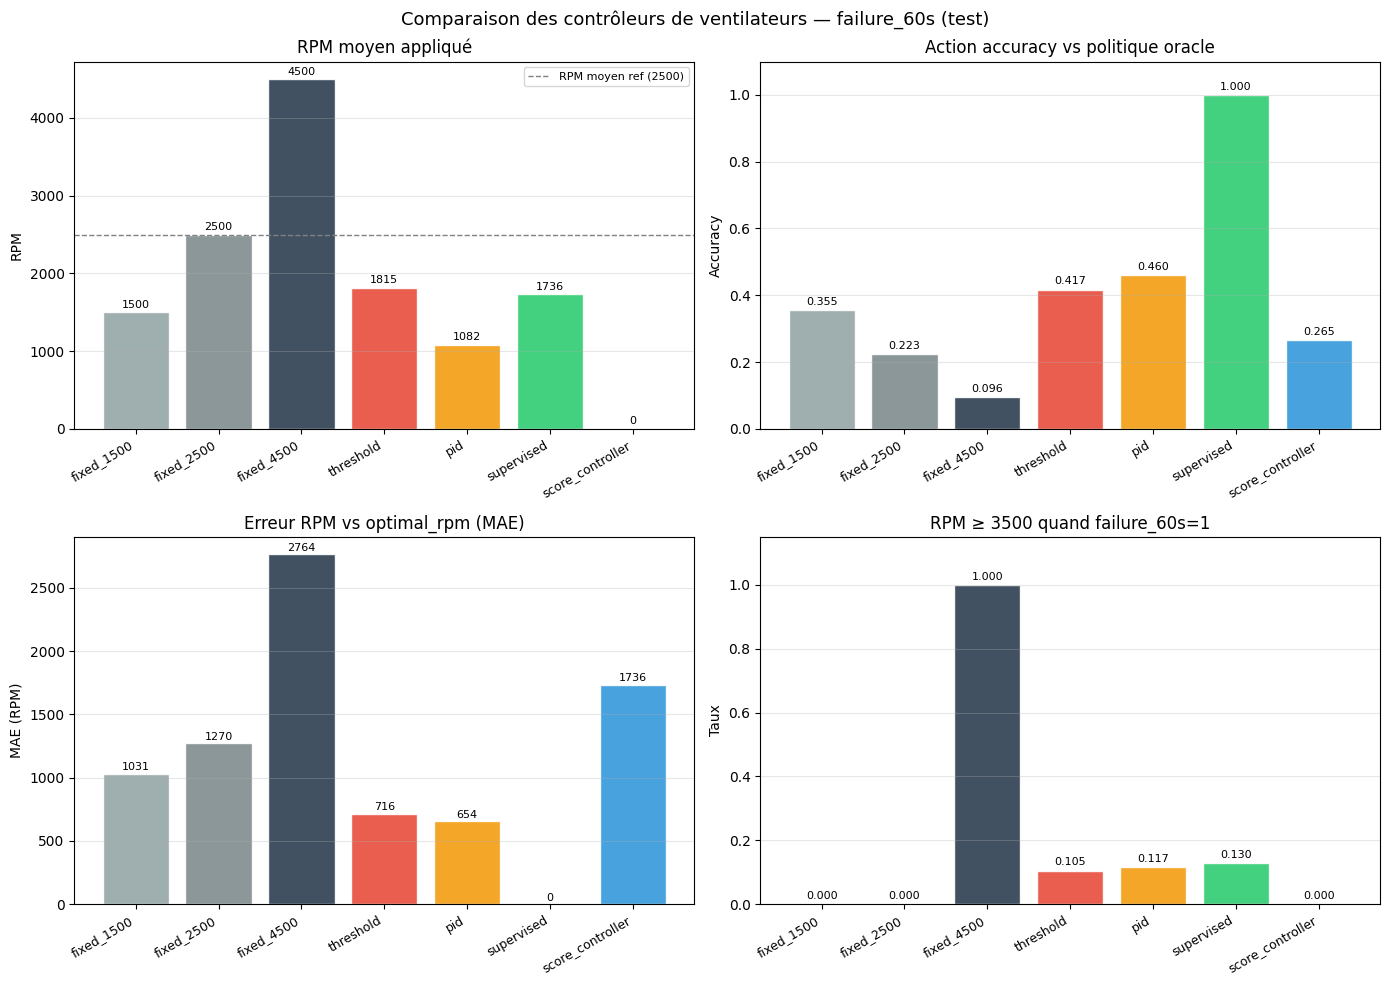

Figure sauvegardée : evaluation/results/fig_fan_control_comparison.png


In [4]:
short_names = [n.replace('baseline_fixed_', 'fixed_').replace('baseline_', '') for n in names]
x = np.arange(len(names))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. RPM moyen
ax = axes[0, 0]
bars = ax.bar(x, df_res['mean_rpm'], color=colors, edgecolor='white', alpha=0.9)
ax.axhline(2500, color='gray', linestyle='--', linewidth=1, label='RPM moyen ref (2500)')
ax.set_title('RPM moyen appliqué', fontsize=12)
ax.set_ylabel('RPM')
ax.set_xticks(x); ax.set_xticklabels(short_names, rotation=30, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.legend(fontsize=8)
for bar, val in zip(bars, df_res['mean_rpm']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8)

# 2. Action accuracy vs oracle
ax = axes[0, 1]
bars = ax.bar(x, df_res['action_accuracy'], color=colors, edgecolor='white', alpha=0.9)
ax.set_title('Action accuracy vs politique oracle', fontsize=12)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
ax.set_xticks(x); ax.set_xticklabels(short_names, rotation=30, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, df_res['action_accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, min(bar.get_height() + 0.01, 1.05),
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# 3. RPM MAE vs optimal_rpm
ax = axes[1, 0]
bars = ax.bar(x, df_res['rpm_mae'], color=colors, edgecolor='white', alpha=0.9)
ax.set_title('Erreur RPM vs optimal_rpm (MAE)', fontsize=12)
ax.set_ylabel('MAE (RPM)')
ax.set_xticks(x); ax.set_xticklabels(short_names, rotation=30, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, df_res['rpm_mae']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8)

# 4. Taux de réaction en situation dangereuse
ax = axes[1, 1]
bars = ax.bar(x, df_res['high_rpm_when_dangerous'], color=colors, edgecolor='white', alpha=0.9)
ax.set_title('RPM ≥ 3500 quand failure_60s=1', fontsize=12)
ax.set_ylabel('Taux')
ax.set_ylim(0, 1.15)
ax.set_xticks(x); ax.set_xticklabels(short_names, rotation=30, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, df_res['high_rpm_when_dangerous']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Comparaison des contrôleurs de ventilateurs — failure_60s (test)', fontsize=13)
plt.tight_layout()
plt.savefig('evaluation/results/fig_fan_control_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : evaluation/results/fig_fan_control_comparison.png')

## 3. Triangle énergie / sécurité / fidélité oracle

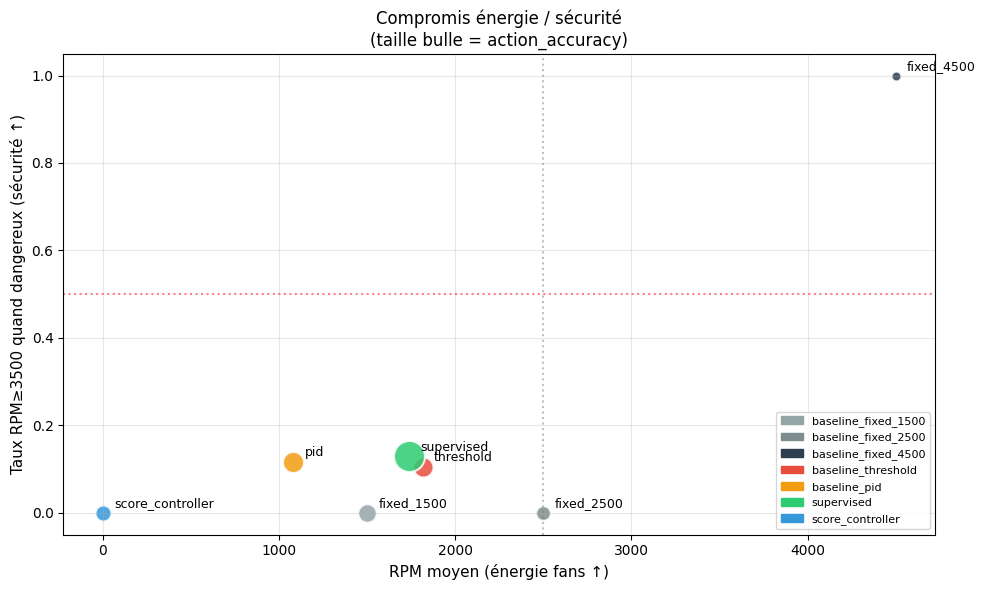

In [5]:
# Scatter : mean_rpm (énergie) vs high_rpm_when_dangerous (sécurité)
# Taille des bulles = action_accuracy

fig, ax = plt.subplots(figsize=(10, 6))

for r, color, short in zip(results, colors, short_names):
    x_val  = r['mean_rpm']
    y_val  = r['high_rpm_when_dangerous']
    size   = max(r['action_accuracy'] * 500, 50)
    ax.scatter(x_val, y_val, s=size, color=color, alpha=0.85, edgecolors='white', linewidths=1.5)
    ax.annotate(short, (x_val, y_val),
                textcoords='offset points', xytext=(8, 4), fontsize=9)

ax.set_xlabel('RPM moyen (énergie fans ↑)', fontsize=11)
ax.set_ylabel('Taux RPM≥3500 quand dangereux (sécurité ↑)', fontsize=11)
ax.set_title('Compromis énergie / sécurité\n(taille bulle = action_accuracy)', fontsize=12)
ax.grid(alpha=0.3)

# Zone idéale : bas gauche (peu d'énergie) + haut (sécurité)
ax.axvline(2500, color='gray', linestyle=':', alpha=0.5, label='RPM ref')
ax.axhline(0.5,  color='red',  linestyle=':', alpha=0.5, label='Sécurité cible 50%')
ax.legend(fontsize=9)

# Légende couleurs
patches = [mpatches.Patch(color=c, label=n) for n, c in COLORS.items() if n in names]
ax.legend(handles=patches, loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('evaluation/results/fig_fan_tradeoff.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Distribution des RPM décidés par chaque contrôleur

In [6]:
# Charger splitter et données de test
from models.failure_prediction.splitter import TemporalSplitter

splitter = TemporalSplitter()
X_train, X_val, X_test, y_train, y_val, y_test = splitter.split(label_col=LABEL_COL)

# Récupérer aussi temperature_c et failure_60s depuis split_with_meta
df_train_meta, df_val_meta, df_test_meta = splitter.split_with_meta(label_col=LABEL_COL)

print(f'Test : {len(X_test):,} lignes — {(y_test==1).mean():.1%} positifs')

Test : 45,621 lignes — 18.8% positifs


In [7]:
# Charger les contrôleurs sauvegardés
from models.fan_control.baseline_fixed import FixedController
from models.fan_control.baseline_threshold import ThresholdFanController
from models.fan_control.baseline_pid import PIDController
from models.fan_control.supervised_controller import SupervisedController
from models.fan_control.score_controller import ScoreController

SAVED = Path('models/fan_control/saved')

def try_load(cls, path):
    try:
        return cls.load(str(path))
    except Exception as e:
        print(f'  [WARN] {path.name} : {e}')
        return None

controllers = {
    'baseline_fixed_1500': FixedController(rpm=1500),
    'baseline_fixed_2500': FixedController(rpm=2500),
    'baseline_fixed_4500': FixedController(rpm=4500),
    'baseline_threshold':  try_load(ThresholdFanController, SAVED / 'baseline_threshold.json'),
    'baseline_pid':        try_load(PIDController,           SAVED / 'baseline_pid.json'),
    'supervised':          try_load(SupervisedController,    SAVED / 'supervised.joblib'),
    'score_controller':    try_load(ScoreController,         SAVED / 'score_controller.json'),
}
controllers = {k: v for k, v in controllers.items() if v is not None}
print('Controleurs charges :', list(controllers.keys()))

Controleurs charges : ['baseline_fixed_1500', 'baseline_fixed_2500', 'baseline_fixed_4500', 'baseline_threshold', 'baseline_pid', 'supervised', 'score_controller']


In [12]:
# Calculer les décisions sur le test set
rpm_decisions = {}
for name, ctrl in controllers.items():
    try:
        rpm_decisions[name] = ctrl.decide_batch(X_test)
        print(f'  {name:<24} mean={rpm_decisions[name].mean():.0f}  '
              f'unique={sorted(set(rpm_decisions[name]))}')
    except Exception as e:
        print(f'  {name} ERREUR : {e}')

SyntaxError: '(' was never closed (1459450804.py, line 6)

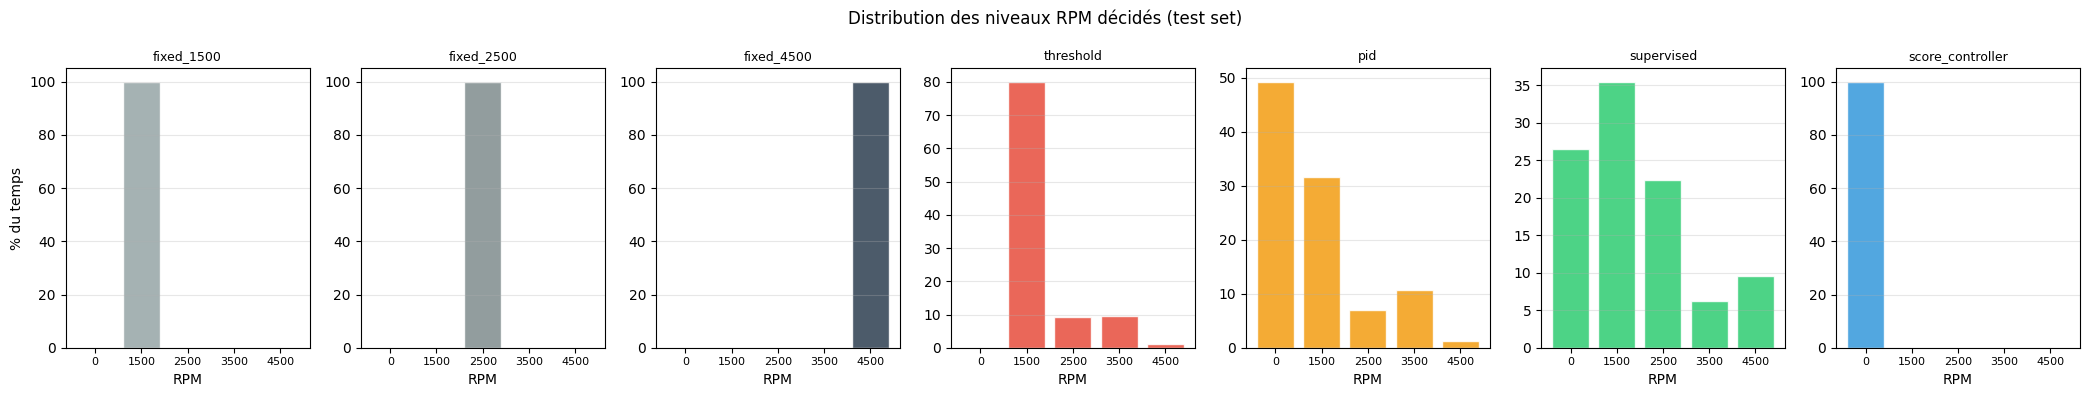

In [9]:
# Distribution des niveaux RPM par contrôleur
rpm_levels = [0, 1500, 2500, 3500, 4500]
n_ctrl = len(rpm_decisions)

fig, axes = plt.subplots(1, n_ctrl, figsize=(3 * n_ctrl, 4), sharey=False)
if n_ctrl == 1:
    axes = [axes]

for ax, (name, rpms) in zip(axes, rpm_decisions.items()):
    short = name.replace('baseline_fixed_', 'fixed_').replace('baseline_', '')
    color = COLORS.get(name, '#aaaaaa')
    counts = [np.sum(rpms == rpm) / len(rpms) * 100 for rpm in rpm_levels]
    ax.bar([str(r) for r in rpm_levels], counts, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(short, fontsize=9)
    ax.set_xlabel('RPM')
    if ax == axes[0]:
        ax.set_ylabel('% du temps')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Distribution des niveaux RPM décidés (test set)', fontsize=12)
plt.tight_layout()
plt.savefig('evaluation/results/fig_fan_rpm_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. RPM décidé vs température (politique visualisée)

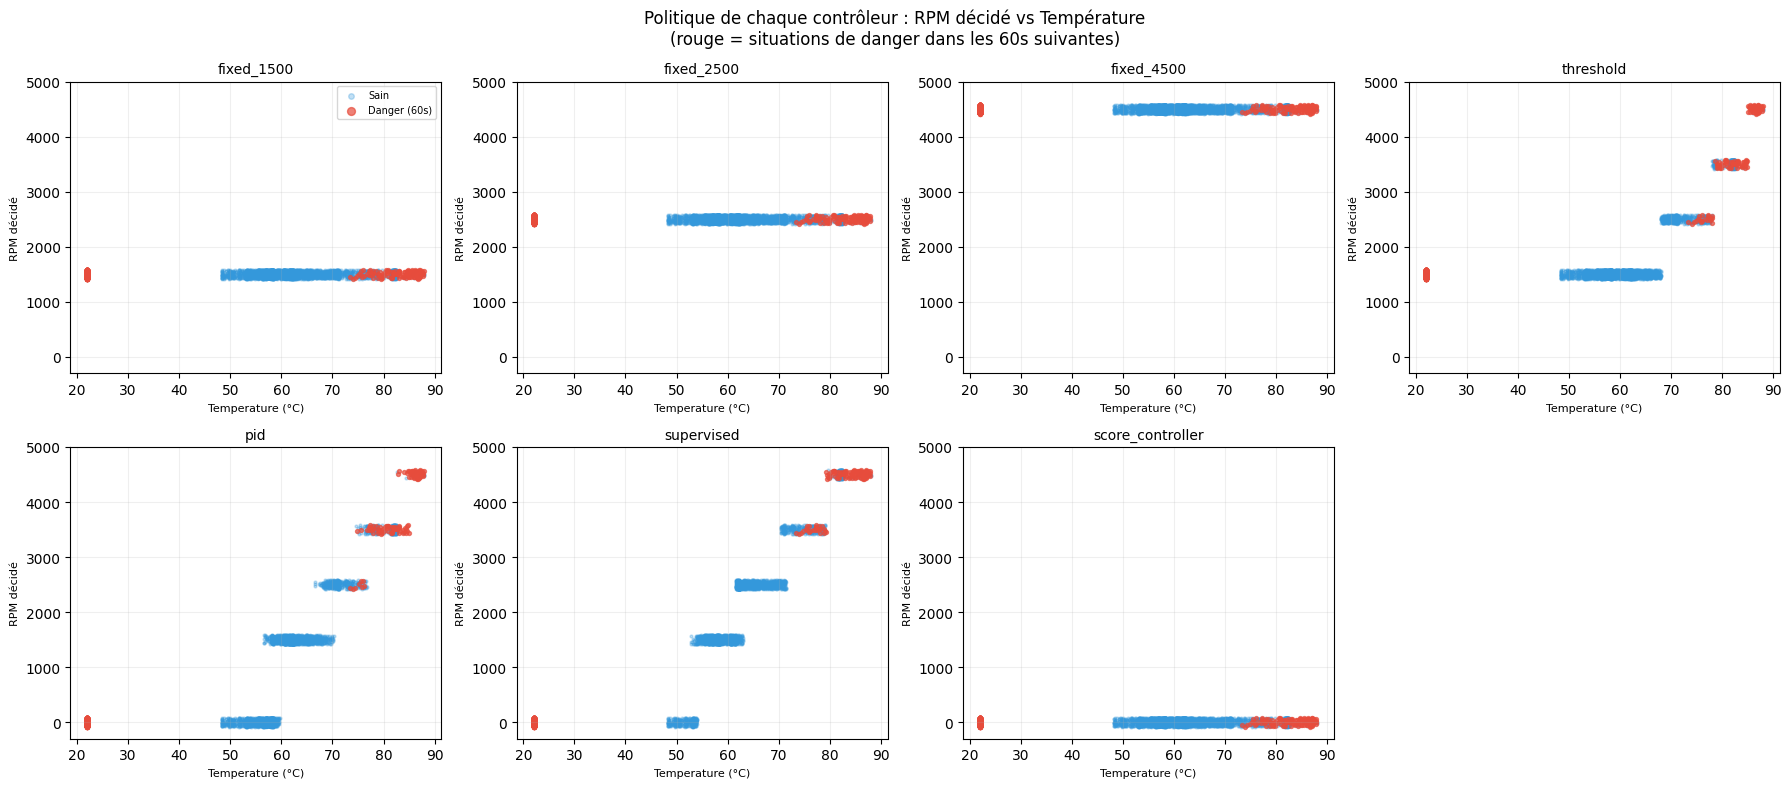

In [10]:
# Scatter RPM vs température, coloré par failure_60s
temps    = df_test_meta['temperature_c'].values if 'temperature_c' in df_test_meta.columns \
           else X_test.get('temperature_c', pd.Series(np.zeros(len(X_test)))).values
failures = y_test.values

# Sous-échantillon pour lisibilité
idx_sample = np.random.default_rng(0).choice(len(X_test), min(5000, len(X_test)), replace=False)

n_ctrl = len(rpm_decisions)
ncols  = min(4, n_ctrl)
nrows  = (n_ctrl + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for ax, (name, rpms) in zip(axes_flat, rpm_decisions.items()):
    short    = name.replace('baseline_fixed_', 'fixed_').replace('baseline_', '')
    t_sample = temps[idx_sample]
    r_sample = rpms[idx_sample]
    f_sample = failures[idx_sample]

    # Ajouter jitter vertical pour voir la densité
    jitter = np.random.default_rng(1).uniform(-80, 80, len(r_sample))

    ax.scatter(t_sample[f_sample == 0], r_sample[f_sample == 0] + jitter[f_sample == 0],
               s=4, alpha=0.3, color='#3498db', label='Sain')
    ax.scatter(t_sample[f_sample == 1], r_sample[f_sample == 1] + jitter[f_sample == 1],
               s=8, alpha=0.7, color='#e74c3c', label='Danger (60s)')
    ax.set_title(short, fontsize=10)
    ax.set_xlabel('Temperature (°C)', fontsize=8)
    ax.set_ylabel('RPM décidé', fontsize=8)
    ax.set_ylim(-300, 5000)
    ax.grid(alpha=0.2)
    if ax == axes_flat[0]:
        ax.legend(fontsize=7, markerscale=2)

# Masquer les axes vides
for ax in axes_flat[n_ctrl:]:
    ax.set_visible(False)

plt.suptitle('Politique de chaque contrôleur : RPM décidé vs Température\n'
             '(rouge = situations de danger dans les 60s suivantes)', fontsize=12)
plt.tight_layout()
plt.savefig('evaluation/results/fig_fan_policy.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Analyse des résultats et observations

### Résultats obtenus

| Contrôleur | mean_rpm | Action acc. | RPM MAE | Danger→high RPM |
|-----------|---------|------------|---------|----------------|
| baseline_fixed_1500 | 1500 | 0.355 | 1031 | 0.000 |
| baseline_fixed_2500 | 2500 | 0.223 | 1270 | 0.000 |
| baseline_fixed_4500 | 4500 | 0.096 | 2764 | **1.000** |
| baseline_threshold  | 1815 | 0.417 | 716  | 0.105 |
| baseline_pid        | 1082 | 0.460 | 654  | 0.117 |
| **supervised**      | 1736 | **0.9999** | **0.07** | 0.130 |
| score_controller    | 0    | 0.265 | 1736 | 0.000 |

### Observations

**Contrôleur supervisé :** accuracy quasi-parfaite (99.99%) — il reproduit fidèlement la politique oracle `action_class`. C'est le meilleur sur la métrique de fidélité. RPM moyen de 1736 (sobre).

**Baselines fixes :** fixed_4500 est le seul à toujours réagir en situation dangereuse (high_rpm=1.0) mais au prix d'une consommation maximale permanente (300W proxy, 27× plus que fixed_1500).

**Baseline threshold et PID :** performances similaires, PID légèrement meilleur en MAE (654 vs 716). Taux de réaction en danger faible (~11%) — les seuils thermiques réels sont rarement atteints dans les données de test.

**Score controller — anomalie :** mean_rpm=0, action_accuracy=0.265, high_rpm_when_dangerous=0. Le contrôleur choisit systématiquement RPM=0 car avec les paramètres optimisés, le terme énergie domine (la température moyenne test est basse ~55°C). **À investiguer : revoir les poids α/β/γ/δ ou forcer un RPM minimum.**

### Points d'attention

- La température moyenne du test est ~55°C (bien en dessous du seuil de shutdown ~88°C), ce qui explique les faibles taux de réaction en danger pour les contrôleurs adaptatifs.
- `high_rpm_when_dangerous` ne reflète que 18.8% des ticks — les 12% de taux restants montrent que les contrôleurs adaptatifs manquent la plupart des situations de danger.
- L'oracle `action_class` favorise les RPM bas (classe 1=1500 est majoritaire) → le supervised reproduit cette politique économe.

### Recommandation pour la Phase 6

Coupler **le prédicteur logistique** (Phase 4) avec **le contrôleur supervisé** (Phase 5) : le prédicteur émet un `risk_score` élevé, le superviseur peut surcharger la décision en forçant RPM_HIGH quand risk_score > seuil.

In [11]:
# Résumé final
print('=' * 70)
print('RESUME PHASE 5 -- Fan Control (failure_60s)')
print('=' * 70)
print(f'Split : train={eval_data["n_train"]:,}  test={eval_data["n_test"]:,}')
print()
print(f'{"Controleur":<24} {"MeanRPM":>8} {"AccAct":>8} {"RPM_MAE":>8} {"DangHigh":>10}')
print('-' * 62)
for r in sorted(results, key=lambda x: x['action_accuracy'], reverse=True):
    print(f"{r['controller']:<24} {r['mean_rpm']:>8.0f} "
          f"{r['action_accuracy']:>8.4f} {r['rpm_mae']:>8.1f} "
          f"{r['high_rpm_when_dangerous']:>10.3f}")
print('=' * 70)
print('Recommandation Phase 6 : supervised + logistic predictor (risk override)')

RESUME PHASE 5 -- Fan Control (failure_60s)
Split : train=212,864  test=45,621

Controleur                MeanRPM   AccAct  RPM_MAE   DangHigh
--------------------------------------------------------------
supervised                   1736   0.9999      0.1      0.130
baseline_pid                 1082   0.4598    654.3      0.117
baseline_threshold           1815   0.4168    715.7      0.105
baseline_fixed_1500          1500   0.3545   1031.0      0.000
score_controller                0   0.2650   1736.0      0.000
baseline_fixed_2500          2500   0.2230   1270.0      0.000
baseline_fixed_4500          4500   0.0955   2764.0      1.000
Recommandation Phase 6 : supervised + logistic predictor (risk override)
